# Session 4 - Querying BigQuery
## From Connection to Simple Analytical SQL

This notebook is part of the *Head of Data 101* end-to-end project.

Goal of this notebook:
- Connect to BigQuery from Python
- Run basic to intermediate SELECT queries
- Inspect and visualize query results

Design principles:
- Every SQL statement is explained in plain English
- Every code line is commented for beginners
- Queries go from simple to more complex
- Focus on reading data, not modifying it

---


## Environment setup (installations)

Before running the notebook, install the required Python packages in the same environment as the notebook kernel.

Minimum required packages:
- `google-cloud-bigquery`
- `db-dtypes`
- `pandas`
- `matplotlib`

Recommended one-liner (includes the pandas extras for BigQuery):
```bash
pip install "google-cloud-bigquery[pandas]" db-dtypes pandas matplotlib
```

If you are using the `.venv` from this repo, run:
```powershell
.\.venv\Scripts\python.exe -m pip install "google-cloud-bigquery[pandas]" db-dtypes pandas matplotlib
```

---


## 1. Prerequisites and context
We will connect to a BigQuery project that already contains the analytical tables.
Project and dataset used in this course:
- Project: `albertheadofdata101`
- Dataset: `autoscout_audi_a3_germany`
Tables (star schema):
- `dim_model` (make, model)
- `dim_fuel` (fuel_type)
- `dim_country` (listing_country)
- `dim_price_label` (price_label)
- `fact_listings` (price, mileage, power_hp, registration, foreign keys)
Important: BigQuery is a paid service. These queries are small, but always be mindful of costs.


## 2. Authentication (one-time setup)

BigQuery needs credentials to know who you are. There are two common options:

Option A: Use your Google account (recommended for local development).
1. Install the Google Cloud SDK
   - Download: https://cloud.google.com/sdk/docs/install
   - Follow the installer steps for your operating system
2. Open a terminal and run the login command:
   - `gcloud auth application-default login`
3. A browser window will open so you can sign in
4. The command stores credentials locally, and your notebook will use them automatically

Option B: Use a service account key (common for servers).
1. Create a service account and download the JSON key
2. Set the environment variable `GOOGLE_APPLICATION_CREDENTIALS` to the JSON file path

We will not store any secrets in the notebook.

---


In [1]:
# Import the libraries we will use for BigQuery and data handling
from google.cloud import bigquery  # BigQuery client library
import pandas as pd  # Work with tabular results in Python
import matplotlib.pyplot as plt  # Create simple charts


In [2]:
# Define the project and dataset we want to work with
project_id = 'albertheadofdata101'  # Replace if your project is different
dataset_id = 'autoscout_audi_a3_germany'  # Dataset where the tables live
# Create a BigQuery client (this uses your default credentials)
client = bigquery.Client(project=project_id)
# Quick check: list the tables in the dataset
tables = client.list_tables(f'{project_id}.{dataset_id}')
[table.table_id for table in tables]  # Show table names


c:\Users\cfuen\OneDrive\Documentos\Clases\Ficheros para clase\Albert\Head of Data 101\Github repo\HeadOfData101\.venv\Lib\site-packages\google\auth\_default.py:108: UserWarning: Your application has authenticated using end user credentials from Google Cloud SDK without a quota project. You might receive a "quota exceeded" or "API not enabled" error. See the following page for troubleshooting: https://cloud.google.com/docs/authentication/adc-troubleshooting/user-creds. 
  warnings.warn(_CLOUD_SDK_CREDENTIALS_WARNING)


['dim_country',
 'dim_fuel',
 'dim_model',
 'dim_price_label',
 'fact_bargain_predictions',
 'fact_listings',
 'fact_price_predictions',
 'fact_top_price_predictions',
 'model_evaluation_summary',
 'stg_listings_clean',
 'vw_bargains_bi']

## 3. A helper function to run SQL and get a DataFrame

We will use a small function to avoid repeating the same boilerplate code.
It runs a SQL query and returns the results as a pandas DataFrame.

---


In [3]:
# Helper: run a SQL query and return a DataFrame
def run_query(sql):
    # Send the SQL query to BigQuery
    query_job = client.query(sql)

    # Wait for the job to finish and download the results
    df = query_job.to_dataframe()

    # Return the DataFrame to the caller
    return df


## 4. Query 1 - List available cars (simple SELECT)
Goal: show a small sample of cars with their basic attributes, including price labels and power.
SQL concepts introduced:
- `SELECT` to choose columns
- `FROM` to pick the table
- `JOIN` to combine fact and dimension tables
- `LIMIT` to avoid huge outputs
We use `fact_listings` for numeric data and join dimensions to get readable labels.


In [4]:
# Build the SQL query as a multi-line string
sql_query_1 = f'''
SELECT
  dm.make AS make,
  dm.model AS model,
  df.fuel_type AS fuel_type,
  dc.listing_country AS listing_country,
  dpl.price_label AS price_label,
  fl.price_eur AS price_eur,
  fl.mileage_km AS mileage_km,
  fl.power_hp AS power_hp
FROM `{project_id}.{dataset_id}.fact_listings` AS fl
JOIN `{project_id}.{dataset_id}.dim_model` AS dm
  ON fl.model_id = dm.model_id
JOIN `{project_id}.{dataset_id}.dim_fuel` AS df
  ON fl.fuel_id = df.fuel_id
JOIN `{project_id}.{dataset_id}.dim_country` AS dc
  ON fl.country_id = dc.country_id
JOIN `{project_id}.{dataset_id}.dim_price_label` AS dpl
  ON fl.price_label_id = dpl.price_label_id
LIMIT 20
'''

# Run the query and store the results
df_q1 = run_query(sql_query_1)

# Show the first rows
df_q1


c:\Users\cfuen\OneDrive\Documentos\Clases\Ficheros para clase\Albert\Head of Data 101\Github repo\HeadOfData101\.venv\Lib\site-packages\google\cloud\bigquery\table.py:1994: UserWarning: BigQuery Storage module not found, fetch data with the REST endpoint instead.
  warnings.warn(


,make,model,fuel_type,listing_country,price_label,price_eur,mileage_km,power_hp
0,audi,a3,2,germany,good-price,26660,29875.0,150.0
1,audi,a3,diesel,germany,fair-price,13300,147000.0,110.0
2,audi,a3,diesel,germany,fair-price,17120,118920.0,116.0
3,audi,a3,diesel,germany,fair-price,23890,73800.0,116.0
4,audi,a3,diesel,germany,fair-price,34780,25095.0,150.0
5,audi,a3,diesel,germany,fair-price,36440,22800.0,150.0
6,audi,a3,diesel,germany,good-price,12480,179900.0,150.0
7,audi,a3,diesel,germany,good-price,16800,80000.0,116.0
8,audi,a3,diesel,germany,good-price,22990,81143.0,150.0
9,audi,a3,diesel,germany,good-price,23550,75025.0,150.0


## 5. Query 2 - Filter by country and fuel type

Goal: select cars from a specific country and engine type.

SQL concepts introduced:
- `WHERE` to filter rows
- Multiple conditions with `AND`

---


In [5]:
# Set the filters we want to use in the query
filter_country = 'germany'  # Example country
filter_fuel = 'diesel'  # Example fuel type

# Build the SQL query using the filters above
sql_query_2 = f'''
SELECT
  dm.make AS make,
  dm.model AS model,
  df.fuel_type AS fuel_type,
  dc.listing_country AS listing_country,
  dpl.price_label AS price_label,
  fl.price_eur AS price_eur,
  fl.power_hp AS power_hp
FROM `{project_id}.{dataset_id}.fact_listings` AS fl
JOIN `{project_id}.{dataset_id}.dim_model` AS dm
  ON fl.model_id = dm.model_id
JOIN `{project_id}.{dataset_id}.dim_fuel` AS df
  ON fl.fuel_id = df.fuel_id
JOIN `{project_id}.{dataset_id}.dim_country` AS dc
  ON fl.country_id = dc.country_id
JOIN `{project_id}.{dataset_id}.dim_price_label` AS dpl
  ON fl.price_label_id = dpl.price_label_id
WHERE dc.listing_country = '{filter_country}'
  AND df.fuel_type = '{filter_fuel}'
LIMIT 20
'''

# Run the query and display results
df_q2 = run_query(sql_query_2)
df_q2


c:\Users\cfuen\OneDrive\Documentos\Clases\Ficheros para clase\Albert\Head of Data 101\Github repo\HeadOfData101\.venv\Lib\site-packages\google\cloud\bigquery\table.py:1994: UserWarning: BigQuery Storage module not found, fetch data with the REST endpoint instead.
  warnings.warn(


,make,model,fuel_type,listing_country,price_label,price_eur,power_hp
0,audi,a3,diesel,germany,fair-price,13300,110.0
1,audi,a3,diesel,germany,fair-price,17120,116.0
2,audi,a3,diesel,germany,fair-price,23890,116.0
3,audi,a3,diesel,germany,fair-price,34780,150.0
4,audi,a3,diesel,germany,fair-price,36440,150.0
5,audi,a3,diesel,germany,good-price,12480,150.0
6,audi,a3,diesel,germany,good-price,16800,116.0
7,audi,a3,diesel,germany,good-price,22990,150.0
8,audi,a3,diesel,germany,good-price,23550,150.0
9,audi,a3,diesel,germany,good-price,26890,150.0


## 6. Query 3 - Top 10 most expensive cars for a model

Goal: find the 10 most expensive listings for a given model.

SQL concepts introduced:
- `ORDER BY` to sort rows
- `DESC` for descending order
- `LIMIT` to keep only the top results

---


In [6]:
# Define the model we want to analyze
target_model = 'a3'  # Example model

# Build the SQL query for the top 10 prices
sql_query_3 = f'''
SELECT
  dm.make AS make,
  dm.model AS model,
  dpl.price_label AS price_label,
  fl.price_eur AS price_eur,
  fl.mileage_km AS mileage_km,
  fl.power_hp AS power_hp,
  df.fuel_type AS fuel_type,
  dc.listing_country AS listing_country
FROM `{project_id}.{dataset_id}.fact_listings` AS fl
JOIN `{project_id}.{dataset_id}.dim_model` AS dm
  ON fl.model_id = dm.model_id
JOIN `{project_id}.{dataset_id}.dim_fuel` AS df
  ON fl.fuel_id = df.fuel_id
JOIN `{project_id}.{dataset_id}.dim_country` AS dc
  ON fl.country_id = dc.country_id
JOIN `{project_id}.{dataset_id}.dim_price_label` AS dpl
  ON fl.price_label_id = dpl.price_label_id
WHERE dm.model = '{target_model}'
ORDER BY fl.price_eur DESC
LIMIT 10
'''

# Run the query and show the top 10 listings
df_q3 = run_query(sql_query_3)
df_q3


c:\Users\cfuen\OneDrive\Documentos\Clases\Ficheros para clase\Albert\Head of Data 101\Github repo\HeadOfData101\.venv\Lib\site-packages\google\cloud\bigquery\table.py:1994: UserWarning: BigQuery Storage module not found, fetch data with the REST endpoint instead.
  warnings.warn(


,make,model,price_label,price_eur,mileage_km,power_hp,fuel_type,listing_country
0,audi,a3,unknown,50790,15000.0,150.0,diesel,germany
1,audi,a3,unknown,49890,4444.0,150.0,diesel,germany
2,audi,a3,unknown,47150,1.0,150.0,petrol,germany
3,audi,a3,unknown,46990,5500.0,150.0,petrol,germany
4,audi,a3,unknown,46930,3000.0,150.0,petrol,germany
5,audi,a3,unknown,45990,15.0,150.0,2,germany
6,audi,a3,unknown,45980,3090.0,150.0,petrol,germany
7,audi,a3,somewhat-expensive,45840,19990.0,190.0,petrol,germany
8,audi,a3,fair-price,44890,16363.0,200.0,diesel,germany
9,audi,a3,somewhat-expensive,43999,12999.0,150.0,diesel,germany


## 7. Query 4 - Count cars by model and price label
Goal: count how many listings each model has by price label.
SQL concepts introduced:
- `COUNT(*)` to count rows
- `GROUP BY` to aggregate by categories
- `ORDER BY` with an aggregated column


In [7]:
# Build the SQL query for counting listings by model and price label
sql_query_4 = f'''
SELECT
  dm.model AS model,
  dpl.price_label AS price_label,
  COUNT(*) AS total_listings
FROM `{project_id}.{dataset_id}.fact_listings` AS fl
JOIN `{project_id}.{dataset_id}.dim_model` AS dm
  ON fl.model_id = dm.model_id
JOIN `{project_id}.{dataset_id}.dim_price_label` AS dpl
  ON fl.price_label_id = dpl.price_label_id
GROUP BY dm.model, dpl.price_label
ORDER BY total_listings DESC
'''

# Run the query and display the results
df_q4 = run_query(sql_query_4)
df_q4.head(10)  # Show the top 10 rows


c:\Users\cfuen\OneDrive\Documentos\Clases\Ficheros para clase\Albert\Head of Data 101\Github repo\HeadOfData101\.venv\Lib\site-packages\google\cloud\bigquery\table.py:1994: UserWarning: BigQuery Storage module not found, fetch data with the REST endpoint instead.
  warnings.warn(


,model,price_label,total_listings
0,a3,fair-price,1124
1,a3,top-price,825
2,a3,good-price,802
3,a3,unknown,284
4,a3,somewhat-expensive,276
5,a3,toolow-price,50
6,a3,expensive,19


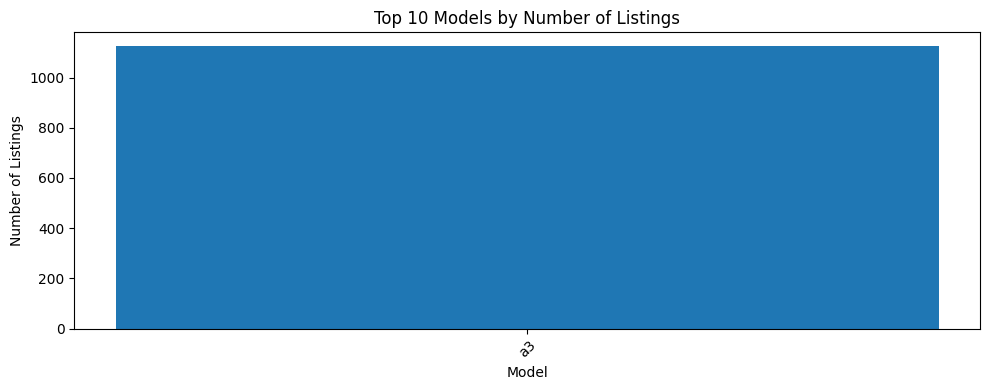

In [8]:
# Plot the top 10 models by number of listings
top10_models = df_q4.head(10)

plt.figure(figsize=(10, 4))
plt.bar(top10_models['model'], top10_models['total_listings'])
plt.title('Top 10 Models by Number of Listings')
plt.xlabel('Model')
plt.ylabel('Number of Listings')
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()


## 8. Query 5 - Count cars by model, country, and price label
Goal: see how listings are distributed across models, countries, and price labels.
SQL concepts introduced:
- `GROUP BY` with more than one column
- Ordering by multiple fields


In [9]:
# Build the SQL query for counts by model, country, and price label
sql_query_5 = f'''
SELECT
  dm.model AS model,
  dc.listing_country AS listing_country,
  dpl.price_label AS price_label,
  COUNT(*) AS total_listings
FROM `{project_id}.{dataset_id}.fact_listings` AS fl
JOIN `{project_id}.{dataset_id}.dim_model` AS dm
  ON fl.model_id = dm.model_id
JOIN `{project_id}.{dataset_id}.dim_country` AS dc
  ON fl.country_id = dc.country_id
JOIN `{project_id}.{dataset_id}.dim_price_label` AS dpl
  ON fl.price_label_id = dpl.price_label_id
GROUP BY dm.model, dc.listing_country, dpl.price_label
ORDER BY dm.model ASC, total_listings DESC
'''

# Run the query and display a sample of the results
df_q5 = run_query(sql_query_5)
df_q5.head(20)


c:\Users\cfuen\OneDrive\Documentos\Clases\Ficheros para clase\Albert\Head of Data 101\Github repo\HeadOfData101\.venv\Lib\site-packages\google\cloud\bigquery\table.py:1994: UserWarning: BigQuery Storage module not found, fetch data with the REST endpoint instead.
  warnings.warn(


,model,listing_country,price_label,total_listings
0,a3,germany,fair-price,1007
1,a3,germany,top-price,741
2,a3,germany,good-price,719
3,a3,germany,unknown,261
4,a3,germany,somewhat-expensive,240
5,a3,unknown,fair-price,117
6,a3,unknown,top-price,84
7,a3,unknown,good-price,83
8,a3,germany,toolow-price,40
9,a3,unknown,somewhat-expensive,36


## 9. Query 6 - Average price and power by model and country
Goal: compare average prices and power across models and countries.
SQL concepts introduced:
- `AVG()` to calculate means
- Rounding for readability


In [10]:
# Build the SQL query for average price and power by model and country
sql_query_6 = f'''
SELECT
  dm.model AS model,
  dc.listing_country AS listing_country,
  ROUND(AVG(fl.price_eur), 2) AS avg_price_eur,
  ROUND(AVG(fl.power_hp), 2) AS avg_power_hp
FROM `{project_id}.{dataset_id}.fact_listings` AS fl
JOIN `{project_id}.{dataset_id}.dim_model` AS dm
  ON fl.model_id = dm.model_id
JOIN `{project_id}.{dataset_id}.dim_country` AS dc
  ON fl.country_id = dc.country_id
GROUP BY dm.model, dc.listing_country
ORDER BY avg_price_eur DESC
'''

# Run the query and show the results
df_q6 = run_query(sql_query_6)
df_q6.head(20)


c:\Users\cfuen\OneDrive\Documentos\Clases\Ficheros para clase\Albert\Head of Data 101\Github repo\HeadOfData101\.venv\Lib\site-packages\google\cloud\bigquery\table.py:1994: UserWarning: BigQuery Storage module not found, fetch data with the REST endpoint instead.
  warnings.warn(


,model,listing_country,avg_price_eur,avg_power_hp
0,a3,germany,21683.45,139.02
1,a3,unknown,18923.35,140.91


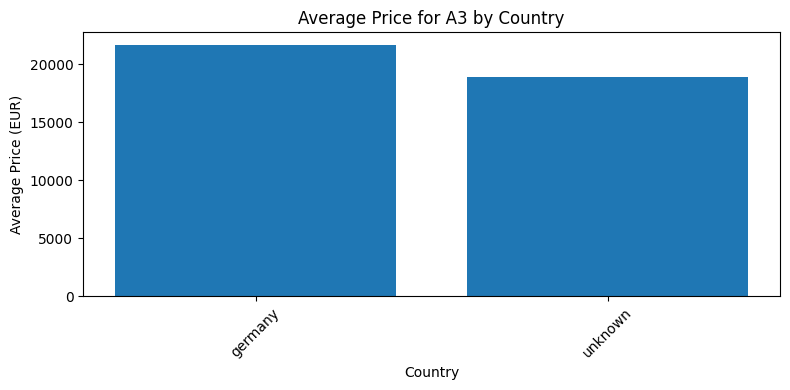

In [11]:
# Visualize the average price for a single model across countries
model_for_plot = 'a3'  # Pick a model you want to compare

# Filter the data for the chosen model
df_model = df_q6[df_q6['model'] == model_for_plot]

plt.figure(figsize=(8, 4))
plt.bar(df_model['listing_country'], df_model['avg_price_eur'])
plt.title(f'Average Price for {model_for_plot.upper()} by Country')
plt.xlabel('Country')
plt.ylabel('Average Price (EUR)')
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()


## 10. Summary

You have now: 
- Connected to BigQuery from Python
- Run multiple SELECT queries from simple to aggregated
- Visualized results with basic charts

Next steps could include:
- Adding filters for year or mileage
- Building a small dashboard
- Comparing brands or makes across countries
